## Fase 2 - entrenamiento final y evaluacion sobre test (MobileNetV2, simetria)

Tras la validacion cruzada (fase 1), se entrena un unico modelo final usando la particion train/val/test original: se entrena con **train**, se monitoriza con **val** (early stopping y reduccion de LR) y se evalua una sola vez sobre **test**.

Tarea: clasificacion de simetria (3 clases). Salidas: metricas finales sobre test y CSV de predicciones imagen a imagen (etiqueta verdadera, predicha y probabilidades por clase) para el estudio estadistico.

In [1]:
import os
import json
import time
import datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    balanced_accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, cohen_kappa_score,
)

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

train_csv  = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/train_onehot.csv"
val_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/val_onehot.csv"
test_csv   = "/home/marc/MARIADELMAR_EXPERIMENTS/onehot_files/test_onehot.csv"
images_dir = "/home/marc/MARIADELMAR_EXPERIMENTS/dataverse_files/images"
sym_csv    = "/home/marc/MARIADELMAR_EXPERIMENTS/ham10000_shape_symmetry_ALL.csv"

IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 3
TASK_NAME   = "symmetry"
CUT_LAYER   = 0
class_names = ["2_ejes", "1_eje", "asimetrica"]

WARMUP_EPOCHS, FT_EPOCHS = 30, 30
WARMUP_LR, FT_LR = 1e-3, 5e-5

EXP_DIR = Path("MobileNetV2_STL") / f"exp_{dt.datetime.now():%Y-%m-%d_%H-%M}_{TASK_NAME}_FASE2_final"
EXP_DIR.mkdir(parents=True, exist_ok=True)
print(f"Experimento fase 2 ({TASK_NAME}) en: {EXP_DIR}")

2026-06-23 11:42:11.817884: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1


Experimento fase 2 (symmetry) en: MobileNetV2_STL/exp_2026-06-23_11-42_symmetry_FASE2_final


In [2]:
PREPROCESS = tf.keras.applications.mobilenet_v2.preprocess_input


df_train = pd.read_csv(train_csv)
df_val   = pd.read_csv(val_csv)
df_test  = pd.read_csv(test_csv)

df_sym = pd.read_csv(sym_csv).rename(columns={"image": "image_id"})[["image_id", "shape_symmetry"]]

def merge_with_sym(df, name):
    before = len(df)
    merged = df.merge(df_sym, on="image_id", how="inner")
    lost   = before - len(merged)
    print(f"  {name}: merge OK, {lost} imagenes perdidas")
    return merged

df_train = merge_with_sym(df_train, "train")
df_val   = merge_with_sym(df_val,   "val")
df_test  = merge_with_sym(df_test,  "test")
for df in (df_train, df_val, df_test):
    df["filepath"] = df["image_id"].apply(lambda x: os.path.join(images_dir, f"{x}.jpg"))

def to_onehot_sym(df):
    y = np.zeros((len(df), NUM_CLASSES), dtype="float32")
    y[np.arange(len(df)), df["shape_symmetry"].values] = 1.0
    return y

y_train = to_onehot_sym(df_train)
y_val   = to_onehot_sym(df_val)
y_test  = to_onehot_sym(df_test)
y_test_int = np.argmax(y_test, axis=1)

print(f"train: {len(df_train)}   val: {len(df_val)}   test: {len(df_test)}")


def load_image(filepath, y, training=False):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    if training:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_flip_up_down(img)
        img = tf.image.random_brightness(img, max_delta=0.2)
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        img = tf.clip_by_value(img, 0.0, 255.0)
    img = PREPROCESS(img)
    return img, y


def make_dataset(filepaths, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((filepaths, y))
    if training:
        ds = ds.shuffle(buffer_size=len(filepaths), reshuffle_each_iteration=True)
    ds = ds.map(lambda f, yy: load_image(f, yy, training), num_parallel_calls=15)
    return ds.batch(BATCH_SIZE).prefetch(50)


train_ds = make_dataset(df_train["filepath"].values, y_train, training=True)
val_ds   = make_dataset(df_val["filepath"].values,   y_val,   training=False)
test_ds  = make_dataset(df_test["filepath"].values,  y_test,  training=False)

  train: merge OK, 0 imagenes perdidas
  val: merge OK, 0 imagenes perdidas
  test: merge OK, 0 imagenes perdidas
train: 6008   val: 2003   test: 2003


2026-06-23 11:42:12.840909: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2026-06-23 11:42:12.860134: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0000:05:00.0 name: GeForce GTX 1080 Ti computeCapability: 6.1
coreClock: 1.582GHz coreCount: 28 deviceMemorySize: 10.91GiB deviceMemoryBandwidth: 451.17GiB/s
2026-06-23 11:42:12.860164: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudart.so.10.1
2026-06-23 11:42:12.861470: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 11:42:12.862673: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcufft.so.10
2026-06-23 11:42:12.862947: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcurand.so

In [3]:
def build_model():
    base_model = tf.keras.applications.MobileNetV2(
        include_top=False, weights="imagenet",
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    )
    base_model.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="input_image")
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(256, activation="relu", name="shared_dense")(x)
    x = tf.keras.layers.Dropout(0.3, name="shared_dropout")(x)
    out = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax", name=f"head_{TASK_NAME}")(x)
    model = tf.keras.Model(inputs, out, name=f"STL_MobileNetV2_{TASK_NAME}")
    return model, base_model


def unfreeze_from(base_model, cut_layer):
    base_model.trainable = True
    for layer in base_model.layers:
        layer.trainable = False
    for i, layer in enumerate(base_model.layers):
        if i >= cut_layer:
            layer.trainable = True

In [4]:
# Class weights balanceados sobre train
y_train_int = np.argmax(y_train, axis=1)
cw = compute_class_weight(class_weight="balanced",
                          classes=np.arange(NUM_CLASSES), y=y_train_int)
class_weight_dict = {i: float(cw[i]) for i in range(NUM_CLASSES)}
print(f"class weights: {cw.round(3)}")

model, base_model = build_model()

print(f"Warmup (head, LR={WARMUP_LR})")
model.compile(optimizer=tf.keras.optimizers.Adam(WARMUP_LR),
              loss="categorical_crossentropy", metrics=["accuracy"])
cb_warmup = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=7, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
t0 = time.time()
h1 = model.fit(train_ds, validation_data=val_ds, epochs=WARMUP_EPOCHS,
               class_weight=class_weight_dict, callbacks=cb_warmup, verbose=2)
t_warmup = time.time() - t0

print(f"Fine-tuning (cut_layer={CUT_LAYER}, LR={FT_LR})")
unfreeze_from(base_model, CUT_LAYER)
model.compile(optimizer=tf.keras.optimizers.Adam(FT_LR),
              loss="categorical_crossentropy", metrics=["accuracy"])
cb_ft = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, min_delta=0.005,
                                     restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3,
                                         min_lr=1e-7, verbose=1),
]
t0 = time.time()
h2 = model.fit(train_ds, validation_data=val_ds, epochs=FT_EPOCHS,
               class_weight=class_weight_dict, callbacks=cb_ft, verbose=2)
t_ft = time.time() - t0

history = {k: list(h1.history.get(k, [])) + list(h2.history.get(k, [])) for k in h1.history}
pd.DataFrame(history).to_csv(EXP_DIR / "history.csv", index=False)
model.save_weights(str(EXP_DIR / "final_weights"), save_format="tf")

class weights: [0.558 1.085 3.477]
Warmup (head, LR=0.001)
Epoch 1/30


2026-06-23 11:42:17.073249: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcublas.so.10
2026-06-23 11:42:17.406372: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcudnn.so.7


188/188 - 10s - loss: 1.1511 - accuracy: 0.4306 - val_loss: 1.0587 - val_accuracy: 0.4408
Epoch 2/30
188/188 - 10s - loss: 1.0224 - accuracy: 0.4687 - val_loss: 0.9521 - val_accuracy: 0.5327
Epoch 3/30
188/188 - 10s - loss: 0.9941 - accuracy: 0.5092 - val_loss: 0.9047 - val_accuracy: 0.5637
Epoch 4/30
188/188 - 9s - loss: 0.9789 - accuracy: 0.5007 - val_loss: 0.9788 - val_accuracy: 0.5032
Epoch 5/30
188/188 - 10s - loss: 0.9672 - accuracy: 0.5092 - val_loss: 1.0033 - val_accuracy: 0.4978
Epoch 6/30

Epoch 00006: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
188/188 - 9s - loss: 0.9482 - accuracy: 0.5205 - val_loss: 0.9184 - val_accuracy: 0.5517
Epoch 7/30
188/188 - 9s - loss: 0.9153 - accuracy: 0.5491 - val_loss: 0.9349 - val_accuracy: 0.5372
Epoch 8/30
188/188 - 9s - loss: 0.8973 - accuracy: 0.5486 - val_loss: 0.9281 - val_accuracy: 0.5427
Epoch 9/30

Epoch 00009: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
188/188 - 9s - loss: 0.8882 - accu

              precision    recall  f1-score   support

      2_ejes     0.8323    0.6738    0.7447      1208
       1_eje     0.4412    0.5464    0.4882       604
  asimetrica     0.3718    0.5393    0.4402       191

    accuracy                         0.6226      2003
   macro avg     0.5484    0.5865    0.5577      2003
weighted avg     0.6705    0.6226    0.6383      2003



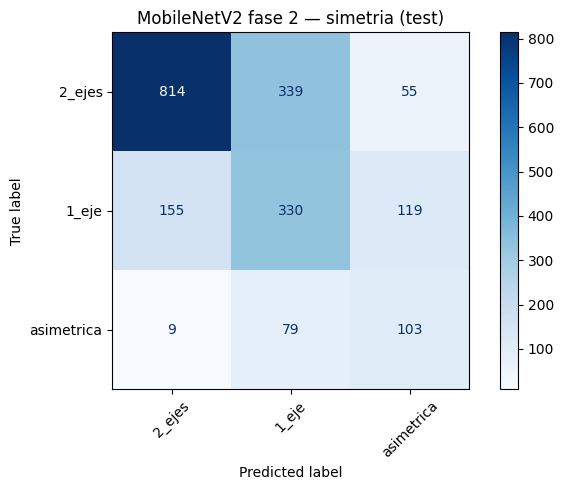


F1 macro test: 0.5577   balanced acc: 0.5865


In [5]:
# Evaluacion unica sobre test
y_pred_proba = model.predict(test_ds, verbose=0)
y_pred_int   = np.argmax(y_pred_proba, axis=1)

metrics = {
    "model":                "MobileNetV2",
    "sym_acc":              float((y_test_int == y_pred_int).mean()),
    "sym_balanced_acc":     float(balanced_accuracy_score(y_test_int, y_pred_int)),
    "sym_precision_macro":  float(precision_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_recall_macro":     float(recall_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_f1_macro":         float(f1_score(y_test_int, y_pred_int, average="macro", zero_division=0)),
    "sym_f1_weighted":      float(f1_score(y_test_int, y_pred_int, average="weighted", zero_division=0)),
    "sym_kappa":            float(cohen_kappa_score(y_test_int, y_pred_int)),
    "epochs_warmup":        len(h1.history["loss"]),
    "epochs_ft":            len(h2.history["loss"]),
    "time_train_s":         round(t_warmup + t_ft, 1),
}
try:
    metrics["sym_auc_macro"] = float(roc_auc_score(
        np.eye(NUM_CLASSES)[y_test_int], y_pred_proba, multi_class="ovr", average="macro"))
except Exception:
    metrics["sym_auc_macro"] = float("nan")

(EXP_DIR / "metrics_FASE2.json").write_text(json.dumps(metrics, indent=2))
pd.DataFrame([metrics]).to_csv(EXP_DIR / "metrics_FASE2.csv", index=False)

rpt = classification_report(y_test_int, y_pred_int, target_names=class_names, digits=4)
(EXP_DIR / "classification_report_symmetry.txt").write_text(rpt)
print(rpt)

cm = confusion_matrix(y_test_int, y_pred_int)
np.save(EXP_DIR / "confusion_matrix_symmetry.npy", cm)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
ax.set_title("MobileNetV2 fase 2 - simetria (test)")
plt.tight_layout(); plt.savefig(EXP_DIR / "confusion_matrix_symmetry.png", dpi=120); plt.show()

print(f"\nF1 macro test: {metrics['sym_f1_macro']:.4f}   "
      f"balanced acc: {metrics['sym_balanced_acc']:.4f}")

CSV imagen a imagen guardado en:
  MobileNetV2_STL/exp_2026-06-23_11-42_symmetry_FASE2_final/predictions_STL_MobileNetV2_symmetry_FASE2.csv
       image_id  true_label  pred_label  true_idx  pred_idx  prob_2_ejes  \
0  ISIC_0028963      2_ejes      2_ejes         0         0     0.956660   
1  ISIC_0028197  asimetrica  asimetrica         2         2     0.198097   
2  ISIC_0028464      2_ejes       1_eje         0         1     0.276885   
3  ISIC_0028002      2_ejes  asimetrica         0         2     0.037931   
4  ISIC_0024568      2_ejes      2_ejes         0         0     0.910293   

   prob_1_eje  prob_asimetrica  
0    0.043305         0.000035  
1    0.346096         0.455806  
2    0.677993         0.045122  
3    0.109898         0.852172  
4    0.089222         0.000485  


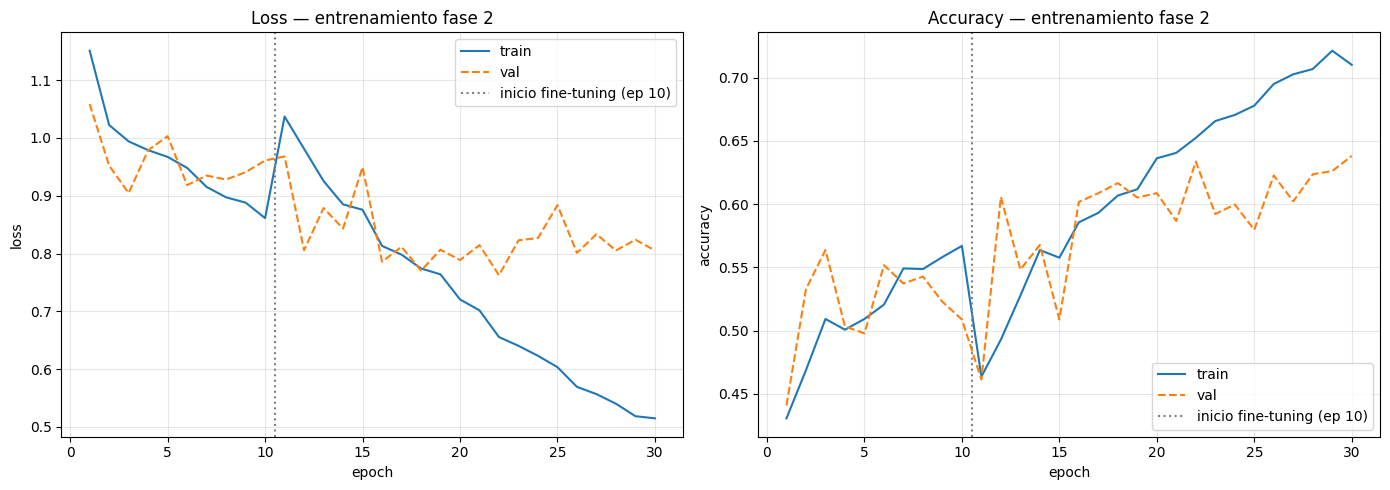

In [6]:
# CSV de predicciones imagen a imagen (entrada del estudio estadistico)
df_pred = pd.DataFrame({
    "image_id":   df_test["image_id"].values,
    "true_label": [class_names[i] for i in y_test_int],
    "pred_label": [class_names[i] for i in y_pred_int],
    "true_idx":   y_test_int,
    "pred_idx":   y_pred_int,
})
for j, c in enumerate(class_names):
    df_pred[f"prob_{c}"] = y_pred_proba[:, j]

out_csv = EXP_DIR / "predictions_STL_MobileNetV2_symmetry_FASE2.csv"
df_pred.to_csv(out_csv, index=False)
print(f"CSV imagen a imagen guardado en:\n  {out_csv}")
print(df_pred.head())

# Curvas de entrenamiento (train vs val)
hist = pd.read_csv(EXP_DIR / "history.csv")
sep  = len(h1.history["loss"])
ep   = np.arange(1, len(hist) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (m_tr, m_va, title) in zip(
        axes, [("loss", "val_loss", "Loss"), ("accuracy", "val_accuracy", "Accuracy")]):
    ax.plot(ep, hist[m_tr], label="train")
    ax.plot(ep, hist[m_va], linestyle="--", label="val")
    ax.axvline(sep + 0.5, color="gray", linestyle=":", label=f"inicio fine-tuning (ep {sep})")
    ax.set_title(f"{title} - entrenamiento fase 2")
    ax.set_xlabel("epoch"); ax.set_ylabel(title.lower()); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(EXP_DIR / "training_curves_fase2.png", dpi=120); plt.show()